# Evaluate Significance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
result_path = '../../data/outputs/segmentation_results/sample/' 

import warnings
warnings.filterwarnings('ignore')

Instead of plotting dice means, we will plot dice differences for each examples, with the reference of using 100% real data. We will also evaluate significance using a t-test.

In [2]:
def get_l_sig_by_tone(result, l_tone, verbose=False):
    l_sig = []
    for tone in l_tone:
        if tone=='all':
            group_A = result['dice_x']
            group_B = result['dice_y']
        else:
            group_A = result[result['tone']==tone]['dice_x']
            group_B = result[result['tone']==tone]['dice_y']
    
        t_stat, p_val = ttest_ind(group_A, group_B)
        if verbose:
            print('tone ', tone, ' t_stat ', t_stat, ' p_val ', p_val)
    
        # Only add star if significant
        if p_val < 0.05:
            # Choose star text based on p-value
            if p_val < 0.001:
                star = '***'
            elif p_val < 0.01:
                star = '**'
            else:
                star = '*'
        else: 
            star = 'ns'
        l_sig.append(star)
    return l_sig
    
def get_mean_std_by_tone(result, l_tone, return_type = 'mean', verbose=False):
    l_val = []
    for tone in l_tone:
        if tone=='all':
            group = result['diff']
        else:
            group = result[result['tone']==tone]['diff']
        if return_type == 'mean':
            l_val.append(group.mean())
        else:
            l_val.append(group.std())
    return l_val

Plot results

###################################
ISIC patient data prop 0.2 (subset patient data) 


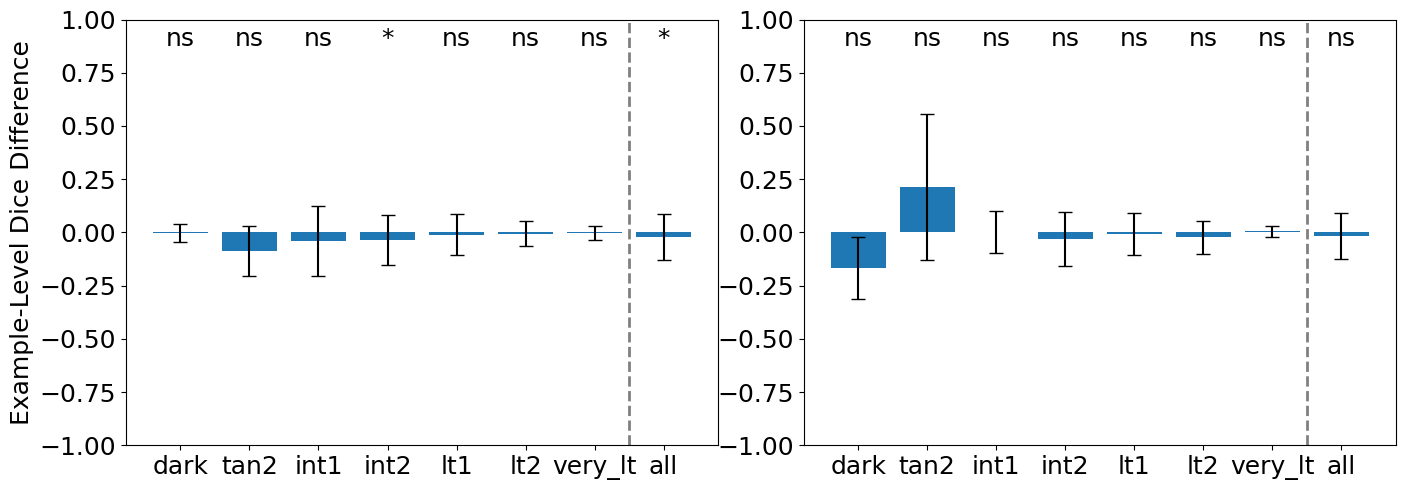

In [4]:
dataset_type = "ISIC" 
method = "replace_with_synth"
FONT_SIZE = 18

for ratio in [0.8]:
    print('###################################')
    if ratio==0.2:
        patient_prop = 0.8
    elif ratio==0.4:
        patient_prop = 0.6 
    elif ratio==0.6:
        patient_prop = 0.4
    elif ratio==0.8:
        patient_prop = 0.2
    elif ratio==1.0:
        patient_prop = 0.0

    print(f'{dataset_type} patient data prop {patient_prop} (subset patient data) ')
    fig, axs = plt.subplots(1, 2, figsize=(2*7,5))
    axs = axs.flatten()

    artifact_ = 'None_10k'
    num = '00'
    file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + f"_{patient_prop}_" + 'add_synth' +'_'+ str(0.0) +'_'+ artifact_ +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + f"_{patient_prop}_" + 'add_synth' +'_'+  str(0.0) +'_'+ artifact_ +'--test_images.csv'
    result_df2 = pd.read_csv(result_path + file)
    
    # get full patient data results
    artifact = 'frame_10k'
    num = '00'
    file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + '_1.0_'+ 'replace_with_synth' +'_'+ str(0.0) +'_'+ artifact +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + '_1.0_' + 'replace_with_synth' +'_'+  str(0.0) +'_'+ artifact +'--test_images.csv'
    result_df1 = pd.read_csv(result_path + file)

    result = pd.merge(result_df1, 
                      result_df2, 
                      on="individual_image_name")
    
    # # check some fields are the same
    assert(result['tone_x'].equals(result['tone_y']))
    assert(result['ita_x'].equals(result['ita_y']))
    result = result.rename(columns={"tone_x": "tone", "ita_x": "ita"}) 
    result = result.drop(columns=['tone_y', 'ita_y'])
    result['diff'] = result['dice_y'] - result['dice_x']
    
    l_tone = ['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all']
    l_sig = get_l_sig_by_tone(result, l_tone=l_tone)
    l_mean = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'mean')
    l_std = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'std')

    ax = axs[0] 
    bar_width = 0.5
    x_pos = np.arange(len(l_tone))
    bars  = ax.bar(x_pos, l_mean, yerr=l_std, 
                label=['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all'],
                capsize = 5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(l_tone, fontsize=FONT_SIZE)
    
    # Add a vertical dashed line before the last bar (Category 'C')
    ax.axvline(x=6.5, color='grey', linestyle='--', linewidth=2)
    ax.set_ylim(-1.0, 1.0)
    
    y_max = ax.get_ylim()[1]
    y_star = y_max * 0.85  # 95% height for stars
    for x_pos in range(len(l_sig)):
        ax.text(x_pos, y_star, l_sig[x_pos], ha='center', va='bottom', fontsize=FONT_SIZE)
    
    ax.set(xlabel=None, ylabel=None)

    #####
    plot_num = 0
    for artifact_sel in ['None_10k']:
        # get synthetic augmented results results
        artifact = artifact_sel
        num = '00'
        file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + '_1.0_'+ method +'_'+ str(ratio) +'_'+ artifact +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + '_1.0_' + method +'_'+  str(ratio) +'_'+ artifact +'--test_images.csv'
        result_df2 = pd.read_csv(result_path + file)

        # get patient data only results
        artifact = 'frame_10k'
        num = '00'
        file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + '_1.0_'+ 'replace_with_synth' +'_'+ str(0.0) +'_'+ artifact +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + '_1.0_' + 'replace_with_synth' +'_'+  str(0.0) +'_'+ artifact +'--test_images.csv'
        result_df1 = pd.read_csv(result_path + file)
    
        result = pd.merge(result_df1, 
                          result_df2, 
                          on="individual_image_name")
        
        # # check some fields are the same
        assert(result['tone_x'].equals(result['tone_y']))
        assert(result['ita_x'].equals(result['ita_y']))
        result = result.rename(columns={"tone_x": "tone", "ita_x": "ita"}) 
        result = result.drop(columns=['tone_y', 'ita_y'])
        result['diff'] = result['dice_y'] - result['dice_x']
        
        l_tone = ['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all']
        l_sig = get_l_sig_by_tone(result, l_tone=l_tone)
        l_mean = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'mean')
        l_std = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'std')

        ax = axs[1] 
        
        bar_width = 0.5
        x_pos = np.arange(len(l_tone))
        bars  = ax.bar(x_pos, l_mean, yerr=l_std, 
                    label=['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all'],
                    capsize = 5)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(l_tone, fontsize=FONT_SIZE)
        
        # Add a vertical dashed line before the last bar (Category 'C')
        ax.axvline(x=6.5, color='grey', linestyle='--', linewidth=2)
        ax.set_ylim(-1.0, 1.0)
        
        y_max = ax.get_ylim()[1]
        y_star = y_max * 0.85  # 95% height for stars
        for x_pos in range(len(l_sig)):
            ax.text(x_pos, y_star, l_sig[x_pos], ha='center', va='bottom', fontsize=FONT_SIZE)
        
        ax.set(xlabel=None, ylabel=None)
        plot_num += 1

    axs[0].set_ylabel('Example-Level Dice Difference', fontsize=FONT_SIZE)
    axs[0].tick_params(axis='y', labelsize=FONT_SIZE)
    axs[1].tick_params(axis='y', labelsize=FONT_SIZE)
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

###################################
HAM patiend data prop 0.2 (subset patient data) 
no examples for dark skin tone!
no examples for dark skin tone!


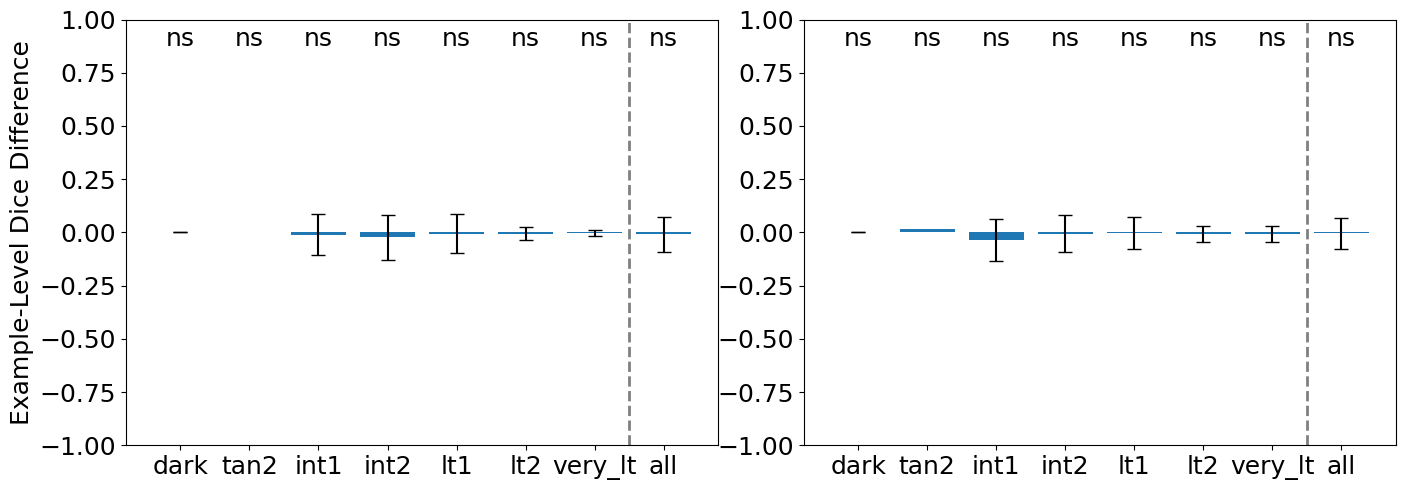

In [5]:
dataset_type = "HAM"
method = "replace_with_synth"
FONT_SIZE = 18

for ratio in [0.8]: 
    print('###################################')
    if ratio==0.2:
        patient_prop = 0.8
    elif ratio==0.4:
        patient_prop = 0.6 
    elif ratio==0.6:
        patient_prop = 0.4
    elif ratio==0.8:
        patient_prop = 0.2
    elif ratio==1.0:
        patient_prop = 0.0

    print(f'{dataset_type} patiend data prop {patient_prop} (subset patient data) ')
    fig, axs = plt.subplots(1, 2, figsize=(2*7,5))
    axs = axs.flatten()

    artifact_ = 'None_10k'
    num = '00'
    file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + f"_{patient_prop}_" + 'add_synth' +'_'+ str(0.0) +'_'+ artifact_ +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + f"_{patient_prop}_" + 'add_synth' +'_'+  str(0.0) +'_'+ artifact_ +'--test_images.csv'
    result_df2 = pd.read_csv(result_path + file)

    # get full patient data results
    artifact = 'frame_10k'
    num = '00'
    file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + '_1.0_'+ 'replace_with_synth' +'_'+ str(0.0) +'_'+ artifact +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + '_1.0_' + 'replace_with_synth' +'_'+  str(0.0) +'_'+ artifact +'--test_images.csv'
    result_df1 = pd.read_csv(result_path + file)
    
    result = pd.merge(result_df1, 
                      result_df2, 
                      on="individual_image_name")
    
    # # check some fields are the same
    assert(result['tone_x'].equals(result['tone_y']))
    assert(result['ita_x'].equals(result['ita_y']))
    result = result.rename(columns={"tone_x": "tone", "ita_x": "ita"}) 
    result = result.drop(columns=['tone_y', 'ita_y'])
    result['diff'] = result['dice_y'] - result['dice_x']
    
    l_tone = ['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all']
    l_sig = get_l_sig_by_tone(result, l_tone=l_tone)
    l_mean = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'mean')
    l_std = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'std')

    if np.isnan(l_mean[0]):
        print('no examples for dark skin tone!')
        l_mean[0] = 0
        l_std[0] = 0
        # l_sig[0] = ''
        
    # ax = axs[plot_num]# // 3, plot_num % 3]
    ax = axs[0] 
    bar_width = 0.5
    x_pos = np.arange(len(l_tone))
    bars  = ax.bar(x_pos, l_mean, yerr=l_std, 
                label=['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all'],
                capsize = 5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(l_tone, fontsize=FONT_SIZE)
    
    # Add a vertical dashed line before the last bar (Category 'C')
    ax.axvline(x=6.5, color='grey', linestyle='--', linewidth=2)
    ax.set_ylim(-1.0, 1.0)
    
    y_max = ax.get_ylim()[1]
    y_star = y_max * 0.85  # 95% height for stars
    for x_pos in range(len(l_sig)):
        ax.text(x_pos, y_star, l_sig[x_pos], ha='center', va='bottom', fontsize=FONT_SIZE)
    
    ax.set(xlabel=None, ylabel=None)

    #####
    plot_num = 0
    for artifact_sel in ['None_10k']:
        # get synthetic augmented results results
        artifact = artifact_sel
        num = '00'
        file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + '_1.0_'+ method +'_'+ str(ratio) +'_'+ artifact +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + '_1.0_' + method +'_'+  str(ratio) +'_'+ artifact +'--test_images.csv'
        result_df2 = pd.read_csv(result_path + file)

        # get patient data only results
        artifact = 'frame_10k'
        num = '00'
        file = 'MODEL-dermosegdiff--all_tones_real_' + dataset_type + '_1.0_'+ 'replace_with_synth' +'_'+ str(0.0) +'_'+ artifact +'--'+ num +'--dsd_i01--n-dsd_i01_s-128_b-32_t-250_sc-linear_best.pth-DATASET-all_tones_real_' + dataset_type + '_1.0_' + 'replace_with_synth' +'_'+  str(0.0) +'_'+ artifact +'--test_images.csv'
        result_df1 = pd.read_csv(result_path + file)

        result = pd.merge(result_df1, 
                          result_df2, 
                          on="individual_image_name")
        
        # # check some fields are the same
        assert(result['tone_x'].equals(result['tone_y']))
        assert(result['ita_x'].equals(result['ita_y']))
        result = result.rename(columns={"tone_x": "tone", "ita_x": "ita"}) 
        result = result.drop(columns=['tone_y', 'ita_y'])
        result['diff'] = result['dice_y'] - result['dice_x']
        
        l_tone = ['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all']
        l_sig = get_l_sig_by_tone(result, l_tone=l_tone)
        l_mean = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'mean')
        l_std = get_mean_std_by_tone(result, l_tone = l_tone, return_type = 'std')

        if np.isnan(l_mean[0]):
            print('no examples for dark skin tone!')
            l_mean[0] = 0
            l_std[0] = 0
        ax = axs[1] 
        
        bar_width = 0.5
        x_pos = np.arange(len(l_tone))
        bars  = ax.bar(x_pos, l_mean, yerr=l_std, 
                    label=['dark', 'tan2', 'int1', 'int2', 'lt1', 'lt2', 'very_lt', 'all'],
                    capsize = 5)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(l_tone, fontsize=FONT_SIZE)
        
        # Add a vertical dashed line before the last bar (Category 'C')
        ax.axvline(x=6.5, color='grey', linestyle='--', linewidth=2)
        ax.set_ylim(-1.0, 1.0)
        
        y_max = ax.get_ylim()[1]
        y_star = y_max * 0.85  # 95% height for stars
        for x_pos in range(len(l_sig)):
            ax.text(x_pos, y_star, l_sig[x_pos], ha='center', va='bottom', fontsize=FONT_SIZE)
        
        ax.set(xlabel=None, ylabel=None)
        plot_num += 1

    axs[0].set_ylabel('Example-Level Dice Difference', fontsize=FONT_SIZE)
    axs[0].tick_params(axis='y', labelsize=FONT_SIZE)
    axs[1].tick_params(axis='y', labelsize=FONT_SIZE)
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

